In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data_path = "../data/NuclearPowerPlantAccidentData/Operation_csv_data/LOCA/1.csv"

df = pd.read_csv(data_path)

print("数据维度：", df.shape)
print("时间范围：", df["TIME"].min(), "→", df["TIME"].max())
print("变量数量：", len(df.columns))

df.head()

数据维度： (475, 97)
时间范围： 0.0 → 4740.0
变量数量： 97


,TIME,P,TAVG,THA,THB,TCA,TCB,WRCA,WRCB,PSGA,...,MDBR,MCRT,MGAS,TCRT,TSLP,PPM,RRCA,RRCB,RRCO,WFLB
0,0.0,155.500015,310.000000,327.823975,327.823212,292.176056,292.176788,16515.818359,33031.636719,67.000031,...,0.0,0.0,0.0,50.0,50.0,200.0,1.0,1.0,1.0,0.0
1,10.0,155.468201,309.980103,327.805481,327.804688,292.156372,292.157227,16515.818359,33031.636719,66.985603,...,0.0,0.0,0.0,50.0,50.0,200.0,1.0,1.0,1.0,0.0
2,20.0,155.467422,309.977661,327.810486,327.809631,292.151398,292.152252,16515.818359,33031.636719,66.982735,...,0.0,0.0,0.0,50.0,50.0,200.0,1.0,1.0,1.0,0.0
3,30.0,155.471863,309.980225,327.811157,327.810303,292.147369,292.148193,16515.818359,33031.636719,66.979523,...,0.0,0.0,0.0,50.0,50.0,200.0,1.0,1.0,1.0,0.0
4,40.0,155.471069,309.977936,327.811432,327.810577,292.145813,292.146637,16515.818359,33031.636719,66.978615,...,0.0,0.0,0.0,50.0,50.0,200.0,1.0,1.0,1.0,0.0


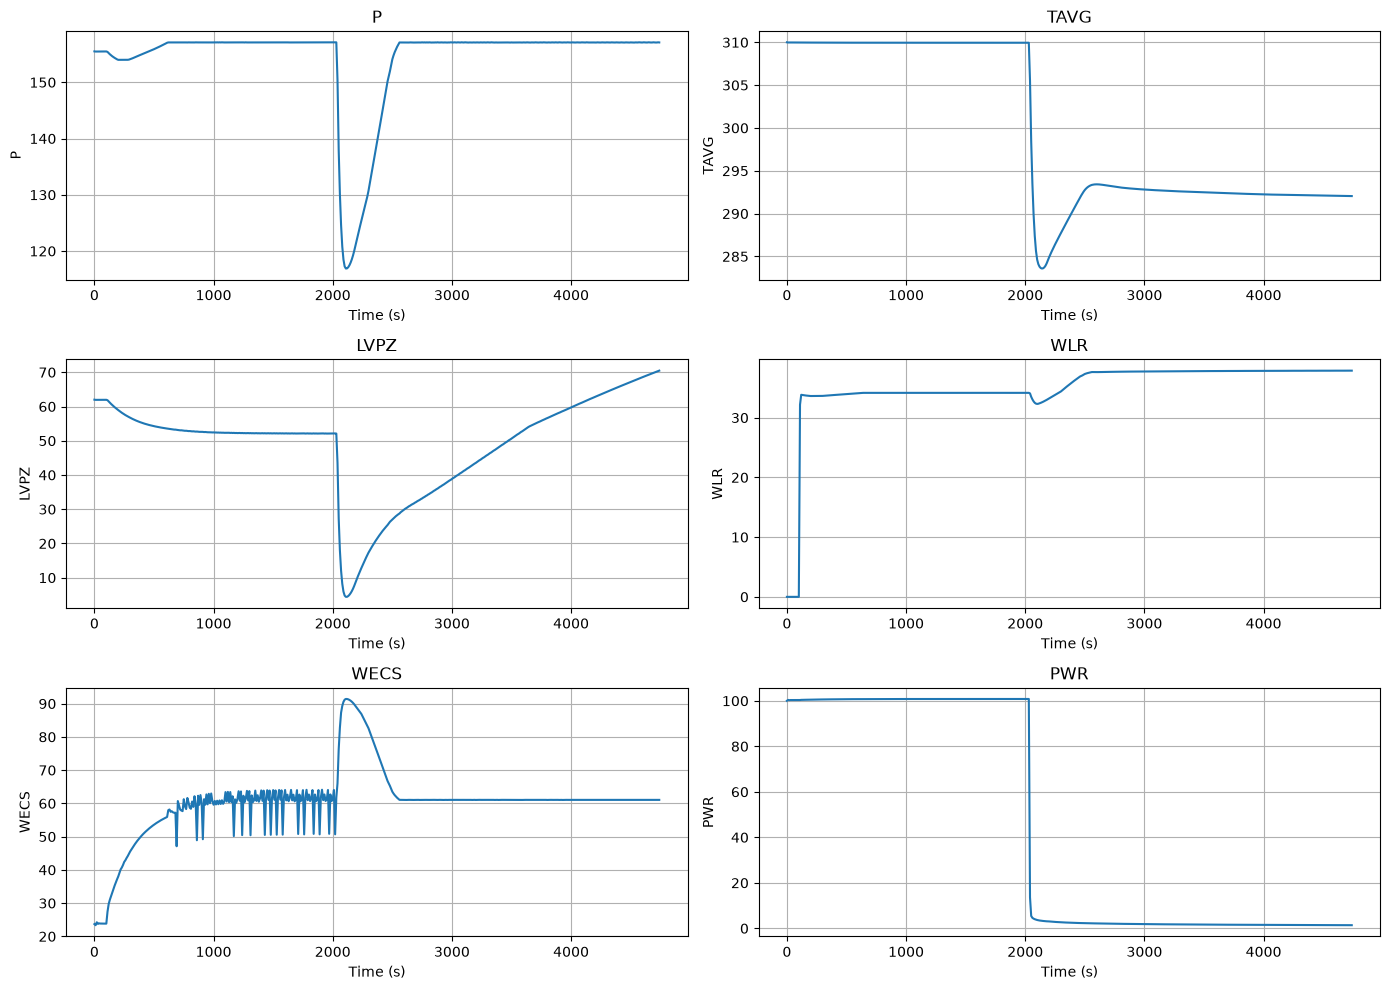

In [2]:
variables = ["P", "TAVG", "LVPZ", "WLR", "WECS", "PWR"]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for ax, var in zip(axes.flat, variables):
    ax.plot(df["TIME"], df[var])
    ax.set_title(var)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(var)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [3]:
window = df[(df["TIME"] >= 1950) & (df["TIME"] <= 2100)]

window[["TIME", "P", "TAVG", "LVPZ", "WLR", "WECS", "PWR"]]

,TIME,P,TAVG,LVPZ,WLR,WECS,PWR
195,1950.0,157.086304,309.948547,52.097488,34.162991,61.243595,100.803154
196,1960.0,157.089722,309.949097,52.103550,34.160000,64.029823,100.804924
197,1970.0,157.086868,309.947205,52.141033,34.160725,50.845230,100.803429
198,1980.0,157.101822,309.948669,52.098942,34.161770,62.691338,100.804871
199,1990.0,157.090317,309.948944,52.125240,34.161724,60.680534,100.803558
200,2000.0,157.086517,309.948029,52.139778,34.159882,61.249805,100.803398
201,2010.0,157.094360,309.949036,52.101475,34.160782,64.024307,100.805138
202,2020.0,157.091599,309.947083,52.139030,34.161537,50.694042,100.803581
203,2030.0,157.106445,309.948608,52.095467,34.162502,61.739178,100.804794
204,2040.0,150.344788,305.520599,43.576126,34.074371,66.025131,13.611048


In [4]:
df["dP"] = df["P"].diff()
df["dP"].nsmallest(10)

205   -12.414246
206    -7.795685
204    -6.761658
207    -5.548744
208    -3.792084
209    -2.317009
210    -1.215988
211    -0.370377
12     -0.219116
13     -0.202271
Name: dP, dtype: float64

In [5]:
accident_start = 0.5

df["TIME_AFTER_ACCIDENT"] = df["TIME"] - accident_start

accident_df = df[df["TIME_AFTER_ACCIDENT"] >= 0].copy()

accident_df[
    ["TIME_AFTER_ACCIDENT", "P", "TAVG", "LVPZ", "WLR", "WECS", "PWR"]
].head(10)

,TIME_AFTER_ACCIDENT,P,TAVG,LVPZ,WLR,WECS,PWR
204,0.0,150.344788,305.520599,43.576126,34.074371,66.025131,13.611048
205,10.0,137.930542,298.403931,27.294922,33.500240,76.254860,5.435982
206,20.0,130.134857,293.511078,17.998951,33.079304,82.750412,4.613528
207,30.0,124.586113,289.910736,12.047058,32.737080,87.292534,4.263447
208,40.0,120.794029,287.376740,8.218498,32.493286,89.305061,4.012997
209,50.0,118.477020,285.653534,5.935884,32.356922,90.539963,3.820457
210,60.0,117.261032,284.626068,4.775126,32.308826,91.197479,3.664035
211,70.0,116.890656,284.097198,4.403099,32.339584,91.405930,3.540658
212,80.0,116.915726,283.805847,4.420524,32.407696,91.399414,3.447380
213,90.0,117.125214,283.648651,4.638193,32.487423,91.294594,3.370231


In [6]:
protection_response_time = 2040

df["TIME_AFTER_PROTECTION"] = (
    df["TIME"] - protection_response_time
)

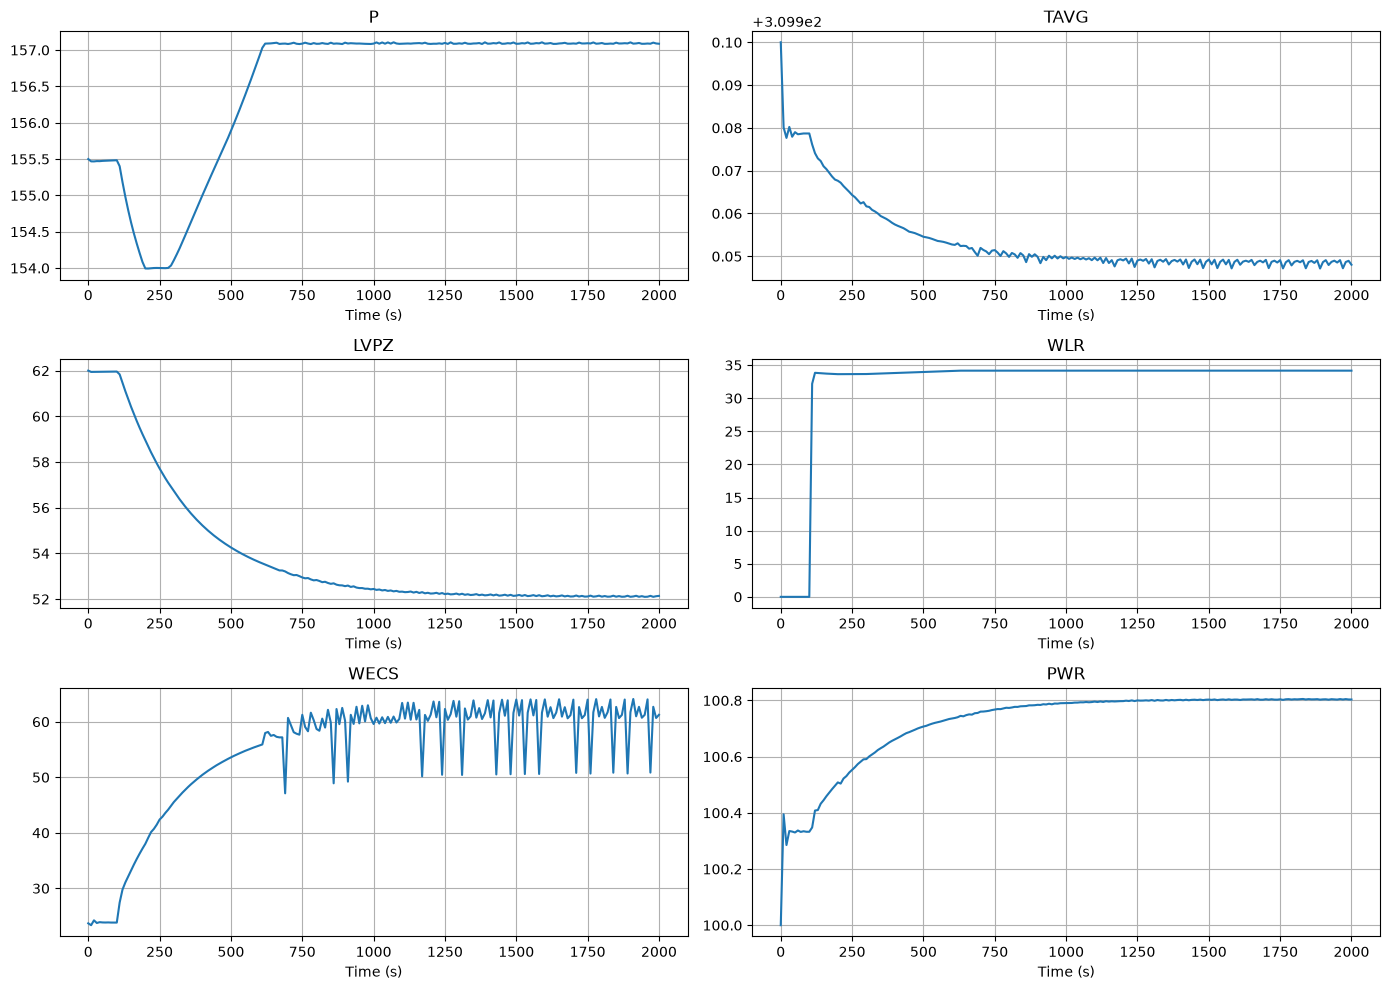

In [7]:
early = df[
    (df["TIME"] >= 0) &
    (df["TIME"] <= 2000)
]

variables = ["P", "TAVG", "LVPZ", "WLR", "WECS", "PWR"]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for ax, var in zip(axes.flat, variables):
    ax.plot(early["TIME"], early[var])
    ax.set_title(var)
    ax.set_xlabel("Time (s)")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [8]:
normal_path = "../data/NuclearPowerPlantAccidentData/Operation_csv_data/Normal/1.csv"
loca_path = "../data/NuclearPowerPlantAccidentData/Operation_csv_data/LOCA/1.csv"

normal_df = pd.read_csv(normal_path)
loca_df = pd.read_csv(loca_path)

print("Normal:", normal_df.shape)
print("LOCA 1%:", loca_df.shape)

print("\n时间范围")
print("Normal:", normal_df["TIME"].min(), "→", normal_df["TIME"].max())
print("LOCA:", loca_df["TIME"].min(), "→", loca_df["TIME"].max())

print("\n列是否完全一致：", list(normal_df.columns) == list(loca_df.columns))

Normal: (302, 97)
LOCA 1%: (475, 97)

时间范围
Normal: 0.0 → 3010.0
LOCA: 0.0 → 4740.0

列是否完全一致： True


In [9]:
check_vars = ["P", "TAVG", "LVPZ", "WLR", "WECS", "PWR"]

comparison = pd.DataFrame({
    "Normal_t0": normal_df.loc[0, check_vars],
    "LOCA_t0": loca_df.loc[0, check_vars]
})

comparison["Difference"] = (
    comparison["LOCA_t0"] - comparison["Normal_t0"]
)

comparison

,Normal_t0,LOCA_t0,Difference
P,155.500015,155.500015,0.0
TAVG,310.000000,310.000000,0.0
LVPZ,62.000000,62.000000,0.0
WLR,0.000000,0.000000,0.0
WECS,23.700001,23.700001,0.0
PWR,100.000000,100.000000,0.0


In [16]:
import numpy as np

# 去掉 TIME，只分析运行参数
features = [c for c in loca_df.columns if c != "TIME"]

def rank_features_at_time(t):
    # 找到相同时间点
    normal_row = normal_df.loc[normal_df["TIME"] == t, features].iloc[0]
    loca_row = loca_df.loc[loca_df["TIME"] == t, features].iloc[0]

    # 用初始值的量级进行归一化，避免不同单位直接比较
    baseline = normal_df.loc[normal_df["TIME"] == 0, features].iloc[0].abs()

    # 防止除以0
    scale = baseline.copy()
    scale[scale < 1e-6] = 1.0

    score = (loca_row - normal_row).abs() / scale

    result = pd.DataFrame({
        "Normal": normal_row,
        "LOCA": loca_row,
        "Abs_Difference": (loca_row - normal_row).abs(),
        "Relative_Score": score
    })

    return result.sort_values("Relative_Score", ascending=False)


rank_100 = rank_features_at_time(100)
rank_100.head(10)

,Normal,LOCA,Abs_Difference,Relative_Score
HTR,210.775332,4.743132,206.032199,206.032199
VOID,0.000005,-0.000003,0.000008,2.810998
WCHG,4.443707,23.834871,19.391164,0.818193
WECS,4.443707,23.834871,19.391164,0.818193
DNBR,2.717186,2.292376,0.424811,0.184700
WSTB,3196.061768,3831.586426,635.524658,0.165866
TBLD,83.413902,100.000000,16.586098,0.165861
WSTA,1598.094727,1915.844604,317.749878,0.165852
PWNT,84.084602,100.332642,16.248039,0.162480
PWR,84.646385,100.332596,15.686211,0.156862


In [15]:
rank_300 = rank_features_at_time(300)
rank_600 = rank_features_at_time(600)

print("===== 100 s =====")
display(rank_100.head(10))

print("===== 300 s =====")
display(rank_300.head(10))

print("===== 600 s =====")
display(rank_600.head(10))

===== 100 s =====


,Normal,LOCA,Abs_Difference,Relative_Score
HTR,210.775332,4.743132,206.032199,206.032199
VOID,0.000005,-0.000003,0.000008,2.810998
WCHG,4.443707,23.834871,19.391164,0.818193
WECS,4.443707,23.834871,19.391164,0.818193
DNBR,2.717186,2.292376,0.424811,0.184700
WSTB,3196.061768,3831.586426,635.524658,0.165866
TBLD,83.413902,100.000000,16.586098,0.165861
WSTA,1598.094727,1915.844604,317.749878,0.165852
PWNT,84.084602,100.332642,16.248039,0.162480
PWR,84.646385,100.332596,15.686211,0.156862


===== 300 s =====


,Normal,LOCA,Abs_Difference,Relative_Score
MBK,0.000000,1822.350464,1822.350464,1822.350464
WRLB,199.914383,0.000000,199.914383,199.914383
SGLK,183.730194,0.000000,183.730194,183.730194
WRLA,99.957146,0.000000,99.957146,99.957146
WLR,0.000000,33.651684,33.651684,33.651684
WBK,0.000000,33.651684,33.651684,33.651684
STRB,0.021269,0.298038,0.276769,13.012743
RM1,0.001100,0.015140,0.014040,12.764017
DTHY,0.001426,0.000283,0.001142,6.761655
DWB,0.000037,0.000095,0.000059,3.460259


===== 600 s =====


,Normal,LOCA,Abs_Difference,Relative_Score
SGLK,45543.625000,0.000000,45543.625000,45543.625000
MBK,0.000000,4646.026367,4646.026367,4646.026367
HTR,1176.999953,862.000000,314.999953,314.999953
WLR,0.000000,34.130566,34.130566,34.130566
WBK,0.000000,34.130566,34.130566,34.130566
STRB,0.021269,0.725432,0.704163,33.107371
RM1,0.001100,0.036816,0.035716,32.468987
RBLK,800.837402,810.199036,9.361633,14.039492
DWB,0.000017,0.000217,0.000200,11.804704
VOID,0.000002,-0.000004,0.000006,2.024784


In [17]:
# 暂时排除直接描述破口/泄漏的变量
excluded_features = ["WLR", "WBK", "MBK"]

indirect_features = [
    c for c in features
    if c not in excluded_features
]

print("原始特征数：", len(features))
print("排除后特征数：", len(indirect_features))

原始特征数： 96
排除后特征数： 93


In [18]:
def rank_indirect_features_at_time(t):

    normal_row = normal_df.loc[
        normal_df["TIME"] == t, indirect_features
    ].iloc[0]

    loca_row = loca_df.loc[
        loca_df["TIME"] == t, indirect_features
    ].iloc[0]

    abs_diff = (loca_row - normal_row).abs()

    result = pd.DataFrame({
        "Normal": normal_row,
        "LOCA": loca_row,
        "Abs_Difference": abs_diff
    })

    return result.sort_values(
        "Abs_Difference",
        ascending=False
    )

In [19]:
for t in [100, 300, 600, 1000, 1500, 2000]:

    print(f"\n===== {t} s =====")

    result = rank_indirect_features_at_time(t)

    display(result.head(10))


===== 100 s =====


,Normal,LOCA,Abs_Difference
WSTB,3196.061768,3831.586426,635.524658
WFWB,3360.737061,3834.029297,473.292236
QMWT,2450.512939,2904.628662,454.115723
WSTA,1598.094727,1915.844604,317.749878
QMGB,1649.137573,1942.208008,293.070435
WFWA,1680.416870,1917.056519,236.639648
HTR,210.775332,4.743132,206.032199
HLW,1307.702515,1501.317017,193.614502
QMGA,824.621094,971.151550,146.530457
TFSB,715.198792,790.471558,75.272766



===== 300 s =====


,Normal,LOCA,Abs_Difference
WFWB,1887.981079,3832.895020,1944.913940
WSTB,2118.525879,3831.575928,1713.050049
QMWT,1449.396484,2912.116699,1462.720215
WFWA,944.104736,1916.506226,972.401489
QMGB,1001.748535,1942.106689,940.358154
WSTA,1059.372437,1915.854736,856.482300
QMGA,500.951080,971.101501,470.150421
TFSB,548.775757,791.697998,242.922241
TFPK,549.186646,791.693176,242.506531
TF,549.186646,791.693176,242.506531



===== 600 s =====


...

,Normal,LOCA,Abs_Difference
SGLK,45543.625000,0.000000,45543.625000
WSTB,1532.535034,3831.585938,2299.050903
WFWB,1545.790161,3831.664062,2285.873901
QMWT,1156.194702,2917.889160,1761.694458
QMGB,774.183411,1941.993286,1167.809875
WSTA,766.437439,1915.844849,1149.407410
WFWA,773.147766,1915.884277,1142.736511
WRCB,33786.125000,33031.636719,754.488281
QMGA,387.203705,971.044434,583.840729
WRCA,16895.537109,16515.818359,379.718750



===== 1500 s =====


,Normal,LOCA,Abs_Difference
SGLK,45543.625000,0.000000,45543.625000
WSTB,1532.558716,3831.585938,2299.027222
WFWB,1534.106079,3831.613037,2297.506958
QMWT,1162.698730,2918.249756,1755.551025
QMGB,775.629333,1942.126221,1166.496887
WSTA,766.413574,1915.844971,1149.431396
WFWA,767.155823,1915.858765,1148.702942
WRCB,33877.261719,33031.636719,845.625000
QMGA,387.901642,971.110962,583.209320
WRCA,16938.205078,16515.818359,422.386719



===== 2000 s =====


,Normal,LOCA,Abs_Difference
SGLK,45543.625000,0.000000,45543.625000
WSTB,1532.558228,3831.586426,2299.028198
WFWB,1532.653198,3831.589844,2298.936646
QMWT,1162.117554,2918.258301,1756.140747
QMGB,775.652405,1942.094238,1166.441833
WSTA,766.414185,1915.844849,1149.430664
WFWA,766.462280,1915.845581,1149.383301
WRCB,33877.261719,33031.636719,845.625000
QMGA,387.916016,971.094788,583.178772
WRCA,16938.205078,16515.818359,422.386719


In [20]:
# 使用项目中的 Normal/1.csv 与 LOCA/1.csv，计算标准化异常分数
import numpy as np
import pandas as pd

normal_path = r"C:\Users\18205\NPP-Guard\Normal\1.csv"
loca_path = r"C:\Users\18205\NPP-Guard\LOCA\1.csv"

normal_std_df = pd.read_csv(normal_path)
loca_std_df = pd.read_csv(loca_path)

# 只保留两份数据共有的运行变量，并排除直接答案型变量
excluded_features = ["WLR", "WBK", "MBK", "SGLK"]
features_std = [
    c for c in normal_std_df.columns
    if c in loca_std_df.columns and c != "TIME" and c not in excluded_features
]

# 用 Normal 的初始阶段建立每个变量的尺度，避免使用 LOCA 数据泄漏答案
baseline_end = 100
normal_base = normal_std_df.loc[
    normal_std_df["TIME"] <= baseline_end, features_std
]

median_scale = normal_base.abs().median()
std_scale = normal_base.std()
scale_std = pd.concat(
    [std_scale, 0.01 * median_scale],
    axis=1
).max(axis=1)
scale_std = scale_std.mask(scale_std < 1e-6)

merged_std = pd.merge(
    normal_std_df[["TIME"] + features_std],
    loca_std_df[["TIME"] + features_std],
    on="TIME",
    suffixes=("_Normal", "_LOCA")
)

standardized_scores = pd.DataFrame({"TIME": merged_std["TIME"]})
for var in features_std:
    standardized_scores[var] = (
        merged_std[f"{var}_LOCA"] - merged_std[f"{var}_Normal"]
    ).abs() / scale_std[var]

def show_standardized_top_features(t, n=10):
    row = standardized_scores.loc[
        standardized_scores["TIME"] == t,
        features_std
    ].iloc[0]
    normal_row = normal_std_df.loc[normal_std_df["TIME"] == t, features_std].iloc[0]
    loca_row = loca_std_df.loc[loca_std_df["TIME"] == t, features_std].iloc[0]
    result = pd.DataFrame({
        "Normal": normal_row,
        "LOCA": loca_row,
        "Anomaly_Score": row
    })
    return result.sort_values("Anomaly_Score", ascending=False).head(n)

print("读取文件：", normal_path, "和", loca_path)
print("候选变量数：", len(features_std))
print("排除变量：", excluded_features)

for t in [100, 300, 600, 1000, 1500, 2000]:
    print(f"\n===== {t} s =====")
    display(show_standardized_top_features(t))


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\18205\\NPP-Guard\\Normal\\1.csv'

In [21]:
# 使用项目实际数据目录中的 Normal/1.csv 与 LOCA/1.csv
normal_path = r"C:\Users\18205\NPP-Guard\data\NuclearPowerPlantAccidentData\Operation_csv_data\Normal\1.csv"
loca_path = r"C:\Users\18205\NPP-Guard\data\NuclearPowerPlantAccidentData\Operation_csv_data\LOCA\1.csv"

normal_std_df = pd.read_csv(normal_path)
loca_std_df = pd.read_csv(loca_path)

# 排除直接答案型变量，只保留两份数据共有的运行变量
excluded_features = ["WLR", "WBK", "MBK", "SGLK"]
features_std = [
    c for c in normal_std_df.columns
    if c in loca_std_df.columns and c != "TIME" and c not in excluded_features
]

# 只用 Normal 的初始阶段建立每个变量的尺度
baseline_end = 100
normal_base = normal_std_df.loc[
    normal_std_df["TIME"] <= baseline_end, features_std
]
median_scale = normal_base.abs().median()
std_scale = normal_base.std()
scale_std = pd.concat(
    [std_scale, 0.01 * median_scale],
    axis=1
).max(axis=1)
scale_std = scale_std.mask(scale_std < 1e-6)

merged_std = pd.merge(
    normal_std_df[["TIME"] + features_std],
    loca_std_df[["TIME"] + features_std],
    on="TIME",
    suffixes=("_Normal", "_LOCA")
)

standardized_scores = pd.DataFrame({"TIME": merged_std["TIME"]})
for var in features_std:
    standardized_scores[var] = (
        merged_std[f"{var}_LOCA"] - merged_std[f"{var}_Normal"]
    ).abs() / scale_std[var]

def show_standardized_top_features(t, n=10):
    row = standardized_scores.loc[
        standardized_scores["TIME"] == t,
        features_std
    ].iloc[0]
    normal_row = normal_std_df.loc[normal_std_df["TIME"] == t, features_std].iloc[0]
    loca_row = loca_std_df.loc[loca_std_df["TIME"] == t, features_std].iloc[0]
    result = pd.DataFrame({
        "Normal": normal_row,
        "LOCA": loca_row,
        "Anomaly_Score": row
    })
    return result.sort_values("Anomaly_Score", ascending=False).head(n)

print("读取文件：", normal_path, "和", loca_path)
print("候选变量数：", len(features_std))
print("排除变量：", excluded_features)

for t in [100, 300, 600, 1000, 1500, 2000]:
    print(f"\n===== {t} s =====")
    display(show_standardized_top_features(t))


读取文件： C:\Users\18205\NPP-Guard\data\NuclearPowerPlantAccidentData\Operation_csv_data\Normal\1.csv 和 C:\Users\18205\NPP-Guard\data\NuclearPowerPlantAccidentData\Operation_csv_data\LOCA\1.csv
候选变量数： 92
排除变量： ['WLR', 'WBK', 'MBK', 'SGLK']

===== 100 s =====


,Normal,LOCA,Anomaly_Score
HLW,1307.702515,1.501317e+03,14.904764
WECS,4.443707,2.383487e+01,3.407806
WCHG,4.443707,2.383487e+01,3.407806
RH,-0.004357,-2.285815e-07,3.214158
WSTB,3196.061768,3.831586e+03,3.006897
TBLD,83.413902,1.000000e+02,3.006848
WSTA,1598.094727,1.915845e+03,3.006751
WFWA,1680.416870,1.917057e+03,2.894007
WFWB,3360.737061,3.834029e+03,2.893569
PWNT,84.084602,1.003326e+02,2.877746



===== 300 s =====


,Normal,LOCA,Anomaly_Score
STRB,0.021269,0.298038,1301.274274
RM1,0.001100,0.015140,1276.401725
DTHY,0.001426,0.000283,676.165520
DNBR,4.593981,2.286481,15.543621
RHRD,-0.451786,0.000000,13.675254
HLW,1338.213989,1501.291016,12.553939
WFWA,944.104736,1916.506226,11.892076
WFWB,1887.981079,3832.895020,11.890631
SCMB,24.773424,16.477459,11.841799
SCMA,24.771898,16.476576,11.841679



===== 600 s =====


...

,Normal,LOCA,Anomaly_Score
STRB,0.021269,1.297278,5999.366821
RM1,0.001100,0.065804,5882.193790
DTHY,0.000169,0.000684,304.605679
RHMT,1.070656,0.005831,69.198369
RHRD,-1.539853,0.000000,46.610262
LVPZ,33.935818,52.443062,29.850394
SCMA,38.292000,18.014967,28.945723
SCMB,38.292984,18.015850,28.943918
DNBR,5.885256,2.281958,24.272288
TRB,50.000000,61.423927,22.847855



===== 1500 s =====


,Normal,LOCA,Anomaly_Score
STRB,0.021269,2.010305,9351.785219
RM1,0.001100,0.101933,9166.616319
DTHY,0.000169,0.000956,465.746316
RHMT,1.149597,0.005898,74.324042
RHRD,-1.618519,0.000000,48.991433
TRB,50.000000,66.573807,33.147614
SCMA,39.697029,18.012119,30.955486
SCMB,39.698860,18.013000,30.954757
LVPZ,33.472111,52.152760,30.130079
DNBR,5.868423,2.281676,24.160794



===== 2000 s =====


,Normal,LOCA,Anomaly_Score
STRB,0.021269,2.721313,12694.704563
RM1,0.001100,0.137943,12440.305271
DTHY,0.000169,0.001217,620.237231
RHMT,1.149293,0.006039,74.295091
RHRD,-1.618519,0.000000,48.991433
TRB,50.000000,71.092636,42.185272
SCMA,39.704998,18.011578,30.967635
SCMB,39.706863,18.012459,30.966954
LVPZ,33.829277,52.139778,29.533066
PRB,1.034000,1.295100,25.251443


In [22]:
import numpy as np
import pandas as pd

# 探索性阈值：分数超过 3，并连续保持 3 个时间点
threshold = 3
min_consecutive = 3

early_scores = (
    standardized_scores
    .query("TIME <= 2000")
    .set_index("TIME")[features_std]
)

rows = []

for var in features_std:
    s = early_scores[var].dropna()

    above = s > threshold
    group_id = above.ne(above.shift()).cumsum()
    run_length = above.groupby(group_id).cumcount() + 1

    alarm_mask = above & (run_length >= min_consecutive)
    alarm_times = s.index[alarm_mask.to_numpy()]

    baseline_median = normal_base[var].abs().median()
    baseline_std = std_scale[var]
    scale_floor = 0.01 * baseline_median

    top10_count = max(1, int(np.ceil(len(s) * 0.10)))

    rows.append({
        "Feature": var,
        "Baseline_Median": baseline_median,
        "Baseline_STD": baseline_std,
        "Scale": scale_std[var],
        "Scale_Floor_Used": bool(baseline_std <= scale_floor),
        "First_Persistent_Alarm": (
            alarm_times[0] if len(alarm_times) else np.nan
        ),
        "Peak_Score": s.max(),
        "Top10_Median_Score": s.nlargest(top10_count).median()
    })

summary = pd.DataFrame(rows)

summary = summary.sort_values(
    [
        "Scale_Floor_Used",
        "First_Persistent_Alarm",
        "Top10_Median_Score"
    ],
    ascending=[True, True, False],
    na_position="last"
)

display(summary.head(20))

# 暂时只看没有使用极小尺度下限的候选变量
candidate_summary = summary[
    (~summary["Scale_Floor_Used"]) &
    summary["First_Persistent_Alarm"].notna()
]

display(candidate_summary.head(15))

,Feature,Baseline_Median,Baseline_STD,Scale,Scale_Floor_Used,First_Persistent_Alarm,Peak_Score,Top10_Median_Score
21,WECS,6.499420,5.690220,5.690220,False,70.0,9.222067,8.565509
62,WCHG,6.499420,5.690220,5.690220,False,70.0,9.222067,8.565509
53,RH,0.004215,0.001355,0.001355,False,70.0,12.157190,4.800898
13,WSTB,3515.422119,211.355634,211.355634,False,120.0,10.878787,10.878628
29,TBLD,91.748627,5.516108,5.516108,False,120.0,10.877235,10.877235
12,WSTA,1757.766846,105.678799,105.678799,False,120.0,10.876818,10.876669
52,RHRD,0.010616,0.033037,0.033037,False,130.0,48.991433,48.991433
35,SCMA,17.989943,0.700519,0.700519,False,130.0,30.969668,30.958728
36,SCMB,17.990826,0.700566,0.700566,False,130.0,30.969037,30.957999
42,DNBR,2.449658,0.148453,0.148453,False,130.0,25.365305,25.267395


,Feature,Baseline_Median,Baseline_STD,Scale,Scale_Floor_Used,First_Persistent_Alarm,Peak_Score,Top10_Median_Score
21,WECS,6.499420,5.690220,5.690220,False,70.0,9.222067,8.565509
62,WCHG,6.499420,5.690220,5.690220,False,70.0,9.222067,8.565509
53,RH,0.004215,0.001355,0.001355,False,70.0,12.157190,4.800898
13,WSTB,3515.422119,211.355634,211.355634,False,120.0,10.878787,10.878628
29,TBLD,91.748627,5.516108,5.516108,False,120.0,10.877235,10.877235
12,WSTA,1757.766846,105.678799,105.678799,False,120.0,10.876818,10.876669
52,RHRD,0.010616,0.033037,0.033037,False,130.0,48.991433,48.991433
35,SCMA,17.989943,0.700519,0.700519,False,130.0,30.969668,30.958728
36,SCMB,17.990826,0.700566,0.700566,False,130.0,30.969037,30.957999
42,DNBR,2.449658,0.148453,0.148453,False,130.0,25.365305,25.267395


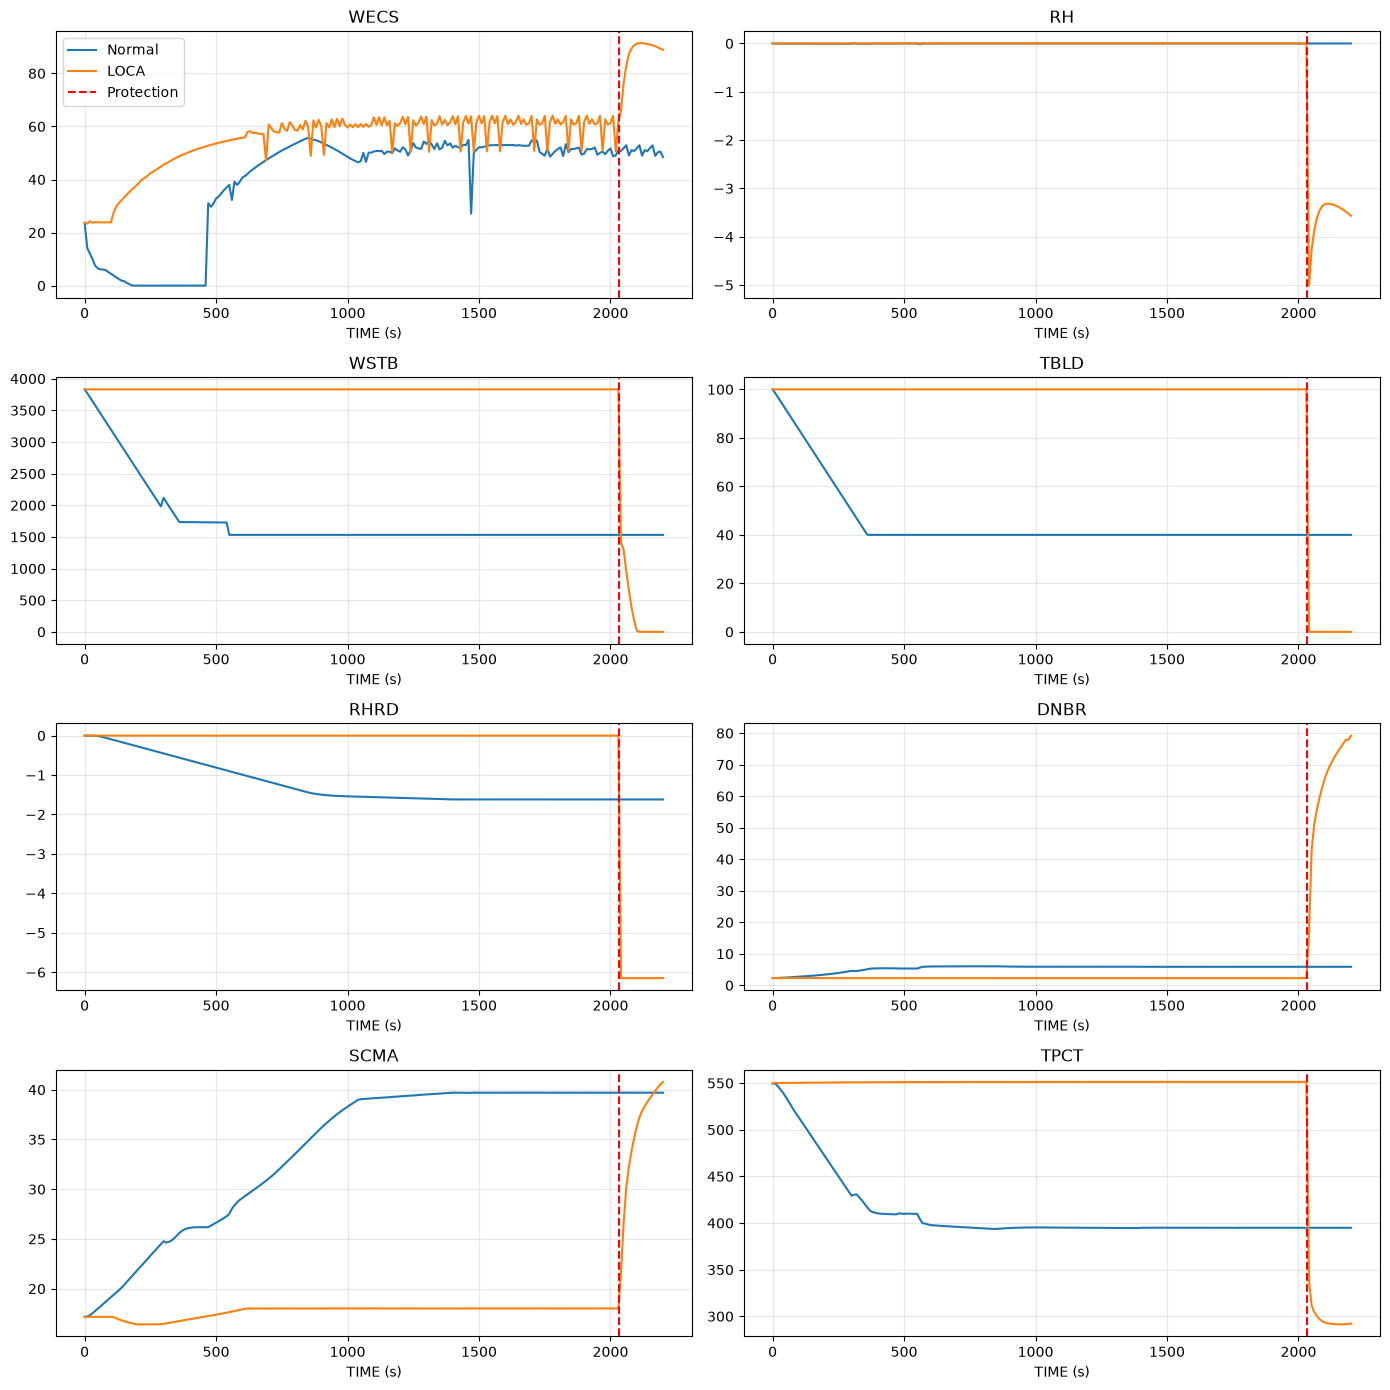

In [23]:
import matplotlib.pyplot as plt

plot_features = [
    "WECS", "RH", "WSTB", "TBLD",
    "RHRD", "DNBR", "SCMA", "TPCT"
]

normal_plot = normal_std_df[normal_std_df["TIME"] <= 2200]
loca_plot = loca_std_df[loca_std_df["TIME"] <= 2200]

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.ravel()

for ax, var in zip(axes, plot_features):
    ax.plot(normal_plot["TIME"], normal_plot[var], label="Normal")
    ax.plot(loca_plot["TIME"], loca_plot[var], label="LOCA")
    ax.axvline(2031.5, color="red", linestyle="--", label="Protection")
    ax.set_title(var)
    ax.set_xlabel("TIME (s)")
    ax.grid(alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

In [24]:
# 基于原始曲线核验后的第一版精简特征
# 暂时排除早期原始幅度不明显、但标准化分数偏高的变量
visual_features = ["WECS", "WSTB", "TBLD", "SCMA", "TPCT"]
held_out_features = ["RH", "RHRD", "DNBR"]

normal_early = normal_std_df.loc[
    normal_std_df["TIME"] <= 2000, visual_features
]
correlation = normal_early.corr()

# 只做初步去冗余：Normal 轨迹相关系数 >= 0.98 时保留先出现的变量
reduced_features = []
for var in visual_features:
    if all(
        pd.isna(correlation.loc[var, kept]) or
        abs(correlation.loc[var, kept]) < 0.98
        for kept in reduced_features
    ):
        reduced_features.append(var)

assert reduced_features

print("图形确认候选：", visual_features)
print("暂缓变量：", held_out_features)
print("初步精简特征：", reduced_features)
print("\nNormal 轨迹相关系数：")
display(correlation.round(3))


图形确认候选： ['WECS', 'WSTB', 'TBLD', 'SCMA', 'TPCT']
暂缓变量： ['RH', 'RHRD', 'DNBR']
初步精简特征： ['WECS', 'WSTB', 'SCMA']

Normal 轨迹相关系数：


,WECS,WSTB,TBLD,SCMA,TPCT
WECS,1.000,-0.704,-0.636,0.881,-0.727
WSTB,-0.704,1.000,0.992,-0.800,0.998
TBLD,-0.636,0.992,1.000,-0.748,0.990
SCMA,0.881,-0.800,-0.748,1.000,-0.820
TPCT,-0.727,0.998,0.990,-0.820,1.000


精简特征： ['WECS', 'WSTB', 'SCMA']
联合分数首次连续 3 个时间点超过 3： 120.0


,Composite_Score
TIME,
100,3.006897
300,8.105060
600,10.877530
1000,10.877642
1500,10.877530
2000,10.877534


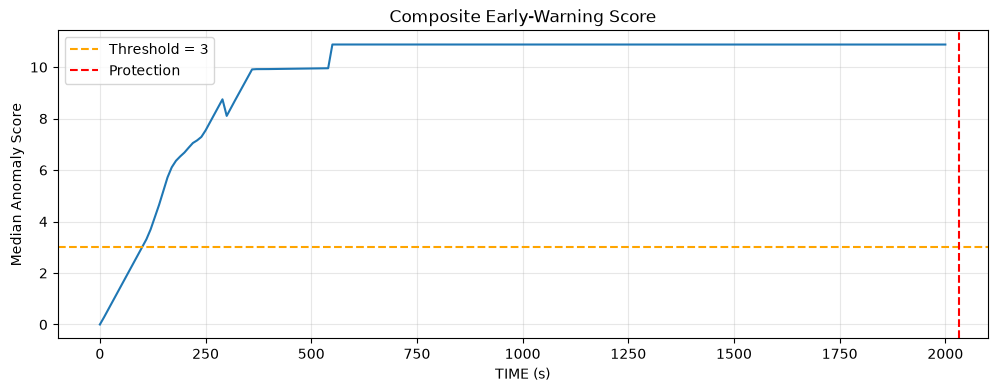

In [25]:
# 用图形确认后的精简特征构造联合早期预警分数
reduced_scores = (
    standardized_scores
    .set_index("TIME")[reduced_features]
    .loc[:2000]
)

# 中位数比平均值更不容易被单个异常变量支配
composite_score = reduced_scores.median(axis=1)

above = composite_score > 3
group_id = above.ne(above.shift()).cumsum()
run_length = above.groupby(group_id).cumcount() + 1
alarm_mask = above & (run_length >= 3)
alarm_times = composite_score.index[alarm_mask.to_numpy()]

print("精简特征：", reduced_features)
print(
    "联合分数首次连续 3 个时间点超过 3：",
    alarm_times[0] if len(alarm_times) else "未触发"
)

check_times = [100, 300, 600, 1000, 1500, 2000]
display(
    pd.DataFrame({
        "Composite_Score": composite_score.reindex(check_times)
    })
)

ax = composite_score.plot(figsize=(12, 4), title="Composite Early-Warning Score")
ax.axhline(3, color="orange", linestyle="--", label="Threshold = 3")
ax.axvline(2031.5, color="red", linestyle="--", label="Protection")
ax.set_xlabel("TIME (s)")
ax.set_ylabel("Median Anomaly Score")
ax.legend()
ax.grid(alpha=0.3)


In [26]:
# 在所有匹配的 Normal/LOCA 案例上验证精简特征
from pathlib import Path

data_root = Path(r"C:\Users\18205\NPP-Guard\data\NuclearPowerPlantAccidentData\Operation_csv_data")
normal_dir = data_root / "Normal"
loca_dir = data_root / "LOCA"

normal_files = {p.name: p for p in normal_dir.glob("*.csv")}
loca_files = {p.name: p for p in loca_dir.glob("*.csv")}
case_names = sorted(set(normal_files) & set(loca_files), key=lambda x: int(Path(x).stem))

if not case_names:
    raise FileNotFoundError("没有找到同名的 Normal/LOCA CSV 案例")

def first_persistent_alarm(score, threshold=3, min_consecutive=3):
    above = score > threshold
    group_id = above.ne(above.shift()).cumsum()
    run_length = above.groupby(group_id).cumcount() + 1
    alarm = above & (run_length >= min_consecutive)
    times = score.index[alarm.to_numpy()]
    return times[0] if len(times) else np.nan

case_rows = []

for case_name in case_names:
    normal_case = pd.read_csv(normal_files[case_name])
    loca_case = pd.read_csv(loca_files[case_name])
    used_features = [
        f for f in reduced_features
        if f in normal_case.columns and f in loca_case.columns
    ]

    normal_base_case = normal_case.loc[
        normal_case["TIME"] <= 100, used_features
    ]
    median_case = normal_base_case.abs().median()
    std_case = normal_base_case.std()
    scale_case = pd.concat(
        [std_case, 0.01 * median_case],
        axis=1
    ).max(axis=1).mask(lambda x: x < 1e-6)

    merged_case = pd.merge(
        normal_case[["TIME"] + used_features],
        loca_case[["TIME"] + used_features],
        on="TIME",
        suffixes=("_Normal", "_LOCA")
    )

    score_case = pd.DataFrame({"TIME": merged_case["TIME"]})
    for var in used_features:
        score_case[var] = (
            merged_case[f"{var}_LOCA"] -
            merged_case[f"{var}_Normal"]
        ).abs() / scale_case[var]

    early_case = score_case.set_index("TIME").loc[:2000, used_features]
    composite_case = early_case.median(axis=1)
    first_alarm = first_persistent_alarm(composite_case)

    case_rows.append({
        "Case": Path(case_name).stem,
        "Features_Used": ", ".join(used_features),
        "First_Persistent_Alarm": first_alarm,
        "Pre_Protection": bool(pd.notna(first_alarm) and first_alarm <= 2031.5),
        "Warning_Margin_s": (
            2031.5 - first_alarm if pd.notna(first_alarm) else np.nan
        ),
        "Score_2000s": composite_case.get(2000, np.nan)
    })

case_summary = pd.DataFrame(case_rows).sort_values(
    "First_Persistent_Alarm", na_position="last"
)

print("匹配案例数：", len(case_summary))
print(
    "2031.5 s 前持续报警：",
    int(case_summary["Pre_Protection"].sum()),
    "/",
    len(case_summary)
)
display(case_summary)


匹配案例数： 1
2031.5 s 前持续报警： 1 / 1


,Case,Features_Used,First_Persistent_Alarm,Pre_Protection,Warning_Margin_s,Score_2000s
0,1,"WECS, WSTB, SCMA",120.0,True,1911.5,10.877534


扫描 LOCA 案例数： 100
2031.5 s 前持续报警： 100 / 100


,LOCA_Case,First_Persistent_Alarm,Pre_Protection,Warning_Margin_s,Score_2000s
0,1,120.0,True,1911.5,10.877534
1,2,120.0,True,1911.5,4.876983
2,3,120.0,True,1911.5,6.965334
3,4,120.0,True,1911.5,7.155483
4,5,120.0,True,1911.5,7.334764
...,...,...,...,...,...
95,96,120.0,True,1911.5,15.181395
96,97,120.0,True,1911.5,27.137776
97,98,120.0,True,1911.5,15.159687
98,99,120.0,True,1911.5,14.188727


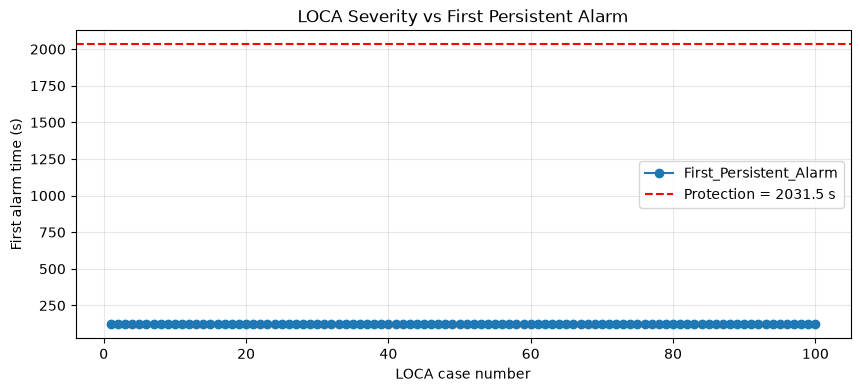

In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_root = Path(
    r"C:\Users\18205\NPP-Guard\data\NuclearPowerPlantAccidentData\Operation_csv_data"
)

normal_df_scan = pd.read_csv(data_root / "Normal" / "1.csv")
loca_files = sorted(
    (data_root / "LOCA").glob("*.csv"),
    key=lambda p: int(p.stem)
)

scan_features = [
    f for f in reduced_features
    if f in normal_df_scan.columns
]

# 只用 Normal/1.csv 建立统一尺度
baseline = normal_df_scan.loc[
    normal_df_scan["TIME"] <= 100,
    scan_features
]

baseline_median = baseline.abs().median()
baseline_std = baseline.std()

scale = pd.concat(
    [baseline_std, 0.01 * baseline_median],
    axis=1
).max(axis=1).mask(lambda x: x < 1e-6)


def first_persistent_alarm(score, threshold=3, min_consecutive=3):
    above = score > threshold
    group_id = above.ne(above.shift()).cumsum()
    run_length = above.groupby(group_id).cumcount() + 1
    alarm = above & (run_length >= min_consecutive)

    alarm_times = score.index[alarm.to_numpy()]
    return alarm_times[0] if len(alarm_times) else np.nan


results = []

for loca_path in loca_files:
    loca_df_scan = pd.read_csv(loca_path)

    features = [
        f for f in scan_features
        if f in loca_df_scan.columns
    ]

    merged = pd.merge(
        normal_df_scan[["TIME"] + features],
        loca_df_scan[["TIME"] + features],
        on="TIME",
        suffixes=("_Normal", "_LOCA")
    )

    scores_case = pd.DataFrame({
        "TIME": merged["TIME"]
    })

    for var in features:
        scores_case[var] = (
            merged[f"{var}_LOCA"] -
            merged[f"{var}_Normal"]
        ).abs() / scale[var]

    early_scores_case = (
        scores_case
        .set_index("TIME")
        .loc[:2000, features]
    )

    composite_case = early_scores_case.median(axis=1)
    first_alarm = first_persistent_alarm(composite_case)

    results.append({
        "LOCA_Case": int(loca_path.stem),
        "First_Persistent_Alarm": first_alarm,
        "Pre_Protection": (
            pd.notna(first_alarm) and first_alarm <= 2031.5
        ),
        "Warning_Margin_s": (
            2031.5 - first_alarm
            if pd.notna(first_alarm)
            else np.nan
        ),
        "Score_2000s": composite_case.get(2000, np.nan)
    })

scan_summary = pd.DataFrame(results).sort_values("LOCA_Case")

print("扫描 LOCA 案例数：", len(scan_summary))
print(
    "2031.5 s 前持续报警：",
    int(scan_summary["Pre_Protection"].sum()),
    "/",
    len(scan_summary)
)

display(scan_summary)

ax = scan_summary.plot(
    x="LOCA_Case",
    y="First_Persistent_Alarm",
    marker="o",
    figsize=(10, 4),
    legend=False,
    title="LOCA Severity vs First Persistent Alarm"
)

ax.axhline(
    2031.5,
    color="red",
    linestyle="--",
    label="Protection = 2031.5 s"
)

ax.set_xlabel("LOCA case number")
ax.set_ylabel("First alarm time (s)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [28]:
print("首次持续报警时间分布：")
display(
    scan_summary["First_Persistent_Alarm"]
    .value_counts()
    .sort_index()
    .rename_axis("Alarm_Time_s")
    .reset_index(name="Cases")
)

print("\n2000 s 联合分数统计：")
print(scan_summary["Score_2000s"].describe())
print(
    "案例编号与 2000 s 分数相关系数：",
    scan_summary[["LOCA_Case", "Score_2000s"]].corr().iloc[0, 1]
)

print("\n分数最低的 10 个案例：")
display(scan_summary.nsmallest(10, "Score_2000s"))

print("分数最高的 10 个案例：")
display(scan_summary.nlargest(10, "Score_2000s"))


首次持续报警时间分布：


,Alarm_Time_s,Cases
0,120.0,100



2000 s 联合分数统计：
count    100.000000
mean      13.742653
std        4.417791
min        4.876983
25%       10.991443
50%       12.715440
75%       14.246059
max       27.137776
Name: Score_2000s, dtype: float64
案例编号与 2000 s 分数相关系数： 0.6420070155471532

分数最低的 10 个案例：


,LOCA_Case,First_Persistent_Alarm,Pre_Protection,Warning_Margin_s,Score_2000s
1,2,120.0,True,1911.5,4.876983
2,3,120.0,True,1911.5,6.965334
3,4,120.0,True,1911.5,7.155483
90,91,120.0,True,1911.5,7.251095
4,5,120.0,True,1911.5,7.334764
5,6,120.0,True,1911.5,8.189313
6,7,120.0,True,1911.5,9.035507
7,8,120.0,True,1911.5,9.776565
8,9,120.0,True,1911.5,10.225298
9,10,120.0,True,1911.5,10.621912


分数最高的 10 个案例：


,LOCA_Case,First_Persistent_Alarm,Pre_Protection,Warning_Margin_s,Score_2000s
96,97,120.0,True,1911.5,27.137776
78,79,120.0,True,1911.5,25.405166
80,81,120.0,True,1911.5,24.737125
76,77,120.0,True,1911.5,24.564986
75,76,120.0,True,1911.5,24.265051
74,75,120.0,True,1911.5,23.871926
71,72,120.0,True,1911.5,22.954876
81,82,120.0,True,1911.5,22.194028
69,70,120.0,True,1911.5,21.842671
65,66,120.0,True,1911.5,21.633036


In [29]:
import sys
print(sys.executable)

C:\Users\18205\NPP-Guard\.venv\Scripts\python.exe


In [30]:
from pathlib import Path
import pyodbc
import pandas as pd
import numpy as np

VAR_ROOT = Path(
    r"C:\Users\18205\NPP-Guard\data\NuclearPowerPlantAccidentData\Variable_Power_Data"
)

def read_variable_power(scenario):
    db_path = VAR_ROOT / scenario / "case1.mdb"

    conn = pyodbc.connect(
        f"DRIVER={{Microsoft Access Driver (*.mdb, *.accdb)}};DBQ={db_path}"
    )

    try:
        df = pd.read_sql("SELECT * FROM PlotData", conn)
    finally:
        conn.close()

    return (
        df.sort_values("TIME")
          .drop_duplicates("TIME")
          .reset_index(drop=True)
    )


def evaluate_pair(normal_test, loca_test, injection_time):
    cols = ["TIME"] + reduced_features

    merged = pd.merge(
        normal_test[cols],
        loca_test[cols],
        on="TIME",
        suffixes=("_Normal", "_LOCA")
    )

    scores = pd.DataFrame({
        feature: (
            merged[f"{feature}_LOCA"]
            - merged[f"{feature}_Normal"]
        ).abs() / float(scale[feature])
        for feature in reduced_features
    })

    scores.index = merged["TIME"]
    composite = scores.median(axis=1)

    alarm = composite > 3
    persistent = alarm.astype(int).rolling(3).sum() >= 3

    first_alarm = (
        persistent.index[persistent][0]
        if persistent.any()
        else np.nan
    )

    before_injection = composite.index < injection_time

    return {
        "First_Persistent_Alarm": first_alarm,
        "Injection_Time": injection_time,
        "Detection_Delay": (
            first_alarm - injection_time
            if pd.notna(first_alarm)
            else np.nan
        ),
        "Pre_Injection_Alarm": bool(
            alarm.loc[before_injection].any()
        ),
        "Max_Pre_Injection_Score": (
            composite.loc[before_injection].max()
        ),
        "Peak_Score": composite.max(),
    }


tests = [
    ("NORM_80_to_100", "LOCA_80_to_100", 2298.5),
    ("NORM_100_to_80", "LOCA_100_to_80", 915.0),
]

results = []

for normal_name, loca_name, injection_time in tests:
    normal_test = read_variable_power(normal_name)
    loca_test = read_variable_power(loca_name)

    result = evaluate_pair(
        normal_test,
        loca_test,
        injection_time
    )

    result["Scenario"] = loca_name
    results.append(result)

display(pd.DataFrame(results))

C:\Users\18205\AppData\Local\Temp\ipykernel_34684\4224805755.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM PlotData", conn)
C:\Users\18205\AppData\Local\Temp\ipykernel_34684\4224805755.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM PlotData", conn)


,First_Persistent_Alarm,Injection_Time,Detection_Delay,Pre_Injection_Alarm,Max_Pre_Injection_Score,Peak_Score,Scenario
0,2350.0,2298.5,51.5,False,0.824462,17.943212,LOCA_80_to_100
1,1000.0,915.0,85.0,False,0.648439,15.897666,LOCA_100_to_80
